# Агентная модель SIR: базовый эксперимент

Агентная версия модели эпидемии. Каждый агент --- человек в одном из
трёх состояний: восприимчивый (`:S`), инфицированный (`:I`) или
выздоровевший (`:R`). Агенты живут в трёх городах и перемещаются
между ними.

Скрипт запускает один эксперимент с параметрами по умолчанию и строит
график динамики.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"

using Agents, DataFrames, Plots
using JLD2

Код модели находится в файле `src/sir_model.jl`:

In [2]:
include(srcdir("sir_model.jl"))

total_count (generic function with 1 method)

## Параметры эксперимента

Три города по 1000 человек. Невыявленный больной заражает в среднем
0.5 человека в день, выявленный --- 0.05. Болезнь длится 14 дней,
выявляют её на 7 день. В начале один больной в третьем городе.

In [3]:
params = Dict(
    :Ns => [1000, 1000, 1000],
    :β_und => [0.5, 0.5, 0.5],
    :β_det => [0.05, 0.05, 0.05],
    :infection_period => 14,
    :detection_time => 7,
    :death_rate => 0.02,
    :reinfection_probability => 0.1,
    :Is => [0, 0, 1],
    :seed => 42,
    :n_steps => 100,
)

Dict{Symbol, Any} with 10 entries:
  :Is                      => [0, 0, 1]
  :seed                    => 42
  :infection_period        => 14
  :n_steps                 => 100
  :β_und                   => [0.5, 0.5, 0.5]
  :Ns                      => [1000, 1000, 1000]
  :detection_time          => 7
  :reinfection_probability => 0.1
  :β_det                   => [0.05, 0.05, 0.05]
  :death_rate              => 0.02

Базовое репродуктивное число по формуле $R_0 = \beta / \gamma$, где
$\gamma = 1 / T$, а $T$ --- длительность болезни:

In [4]:
γ = 1 / params[:infection_period]
R0 = params[:β_und][1] / γ
println("R0 = β/γ = ", R0)

R0 = β/γ = 7.0


## Инициализация модели

In [5]:
model = initialize_sir(; params...)

StandardABM with 3000 agents of type Person
 agents container: Dict
 space: GraphSpace with 3 positions and 3 edges
 scheduler: fastest
 properties: C, infection_period, β_und, Ns, migration_rates, detection_time, reinfection_probability, β_det, death_rate

## Запуск симуляции

Выполняем 100 шагов (дней). После каждого шага считаем число агентов
в каждом состоянии и общее число живых.

In [6]:
times = Int[]
S_vals = Int[]
I_vals = Int[]
R_vals = Int[]
total_vals = Int[]

for step = 1:params[:n_steps]
    Agents.step!(model, 1)

    push!(times, step)
    push!(S_vals, susceptible_count(model))
    push!(I_vals, infected_count(model))
    push!(R_vals, recovered_count(model))
    push!(total_vals, total_count(model))
end

Собираем данные в таблицы:

In [7]:
agent_df = DataFrame(time = times, susceptible = S_vals, infected = I_vals, recovered = R_vals)
model_df = DataFrame(time = times, total = total_vals)
first(agent_df, 5)

Row,time,susceptible,infected,recovered
,Int64,Int64,Int64,Int64
1,1,2998,2,0
2,2,2994,6,0
3,3,2991,9,0
4,4,2985,15,0
5,5,2969,31,0


## Основные показатели

In [8]:
peak_idx = argmax(I_vals)
println("Пик инфицированных: ", I_vals[peak_idx], " на ", times[peak_idx], " день")
println("В конце: S = ", S_vals[end], ", I = ", I_vals[end], ", R = ", R_vals[end])
println("Умерло: ", sum(params[:Ns]) - total_vals[end])

Пик инфицированных: 3000 на 15 день
В конце: S = 0, I = 2640, R = 25
Умерло: 335


## Визуализация

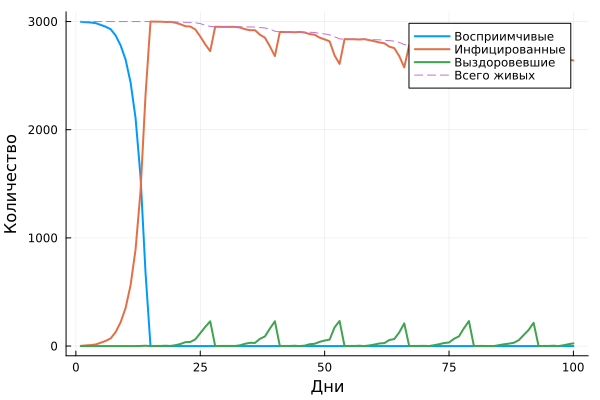

In [9]:
plt = plot(
    agent_df.time,
    agent_df.susceptible,
    label = "Восприимчивые",
    xlabel = "Дни",
    ylabel = "Количество",
    linewidth = 2,
)
plot!(plt, agent_df.time, agent_df.infected, label = "Инфицированные", linewidth = 2)
plot!(plt, agent_df.time, agent_df.recovered, label = "Выздоровевшие", linewidth = 2)
plot!(plt, agent_df.time, model_df.total, label = "Всего живых", linestyle = :dash)
plt

## Сохранение результатов

In [10]:
savefig(plt, plotsdir("sir_basic_dynamics.png"))
@save datadir("sir_basic_agent.jld2") agent_df
@save datadir("sir_basic_model.jld2") model_df